In [ ]:
# Pull the preprocessed data from GitHub
from google.colab import userdata

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
GITHUB_USER = "ThemiyaDeshan"
REPO_NAME = "Y03S01_Machine-Lerning_Assignment"

repo_url = f"https://{GITHUB_TOKEN}@github.com/{GITHUB_USER}/{REPO_NAME}.git"
!git clone {repo_url}

import pandas as pd

data_dir = f"/content/{REPO_NAME}/Data/PreprocessedData"
train_df = pd.read_csv(f"{data_dir}/bank_train.csv")
test_df = pd.read_csv(f"{data_dir}/bank_test.csv")

print(train_df.shape, test_df.shape)

Cloning into 'Y03S01_Machine-Lerning_Assignment'...
remote: Enumerating objects: 37, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 37 (delta 6), reused 8 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (37/37), 1.70 MiB | 12.40 MiB/s, done.
Resolving deltas: 100% (6/6), done.
(36168, 42) (9043, 42)


In [ ]:
# Split into X/y and set up shared evaluation tracking
X_train = train_df.drop(columns=["y"])
y_train = train_df["y"]
X_test = test_df.drop(columns=["y"])
y_test = test_df["y"]

print("Train class balance:\n", y_train.value_counts(normalize=True))

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1": round(f1_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_proba), 4),
    })
    print(f"{name} done.")

Train class balance:
 y
0    0.883018
1    0.116982
Name: proportion, dtype: float64


In [ ]:
# Baseline: Logistic Regression
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

evaluate_model("Logistic Regression (baseline)", log_reg, X_test, y_test)

Logistic Regression (baseline) done.


In [ ]:
# Alternative 1: Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(class_weight="balanced", max_depth=8, random_state=42)
dt.fit(X_train, y_train)

evaluate_model("Decision Tree", dt, X_test, y_test)

Decision Tree done.


In [ ]:
# Alternative 2: Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300, class_weight="balanced", max_depth=12, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

evaluate_model("Random Forest", rf, X_test, y_test)

Random Forest done.


In [ ]:
# Alternative 3: XGBoost
!pip install -q xgboost
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()  # handles imbalance for XGBoost

xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss", random_state=42
)
xgb.fit(X_train, y_train)

evaluate_model("XGBoost", xgb, X_test, y_test)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.4/252.4 MB 1.5 MB/s eta 0:00:00
XGBoost done.


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression (baseline),0.7552,0.2669,0.6257,0.3742,0.7722
1,Decision Tree,0.8326,0.3594,0.5510,0.4351,0.7561
2,Random Forest,0.8363,0.3689,0.5614,0.4453,0.7927
3,XGBoost,0.8267,0.3552,0.5898,0.4433,0.7824


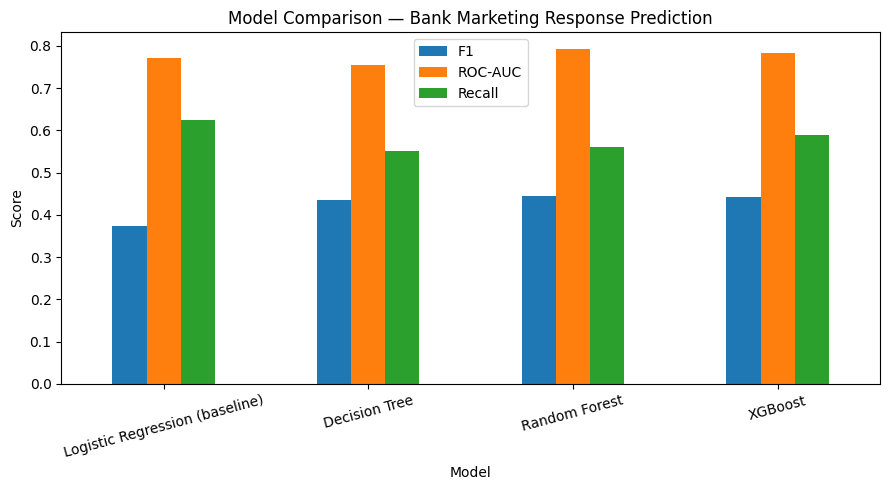

In [ ]:
# Consolidated comparison table + chart
import matplotlib.pyplot as plt

results_df = pd.DataFrame(results)
display(results_df)

results_df.set_index("Model")[["F1", "ROC-AUC", "Recall"]].plot(kind="bar", figsize=(9, 5))
plt.title("Model Comparison — Bank Marketing Response Prediction")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
# PR-AUC (more honest under imbalance)
from sklearn.metrics import average_precision_score

models = {
    "Logistic Regression (baseline)": log_reg,
    "Decision Tree": dt,
    "Random Forest": rf,
    "XGBoost": xgb,
}

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    pr_auc = average_precision_score(y_test, y_proba)
    print(f"{name}: PR-AUC = {pr_auc:.4f}")

Logistic Regression (baseline): PR-AUC = 0.4092
Decision Tree: PR-AUC = 0.3781
Random Forest: PR-AUC = 0.4211
XGBoost: PR-AUC = 0.4311


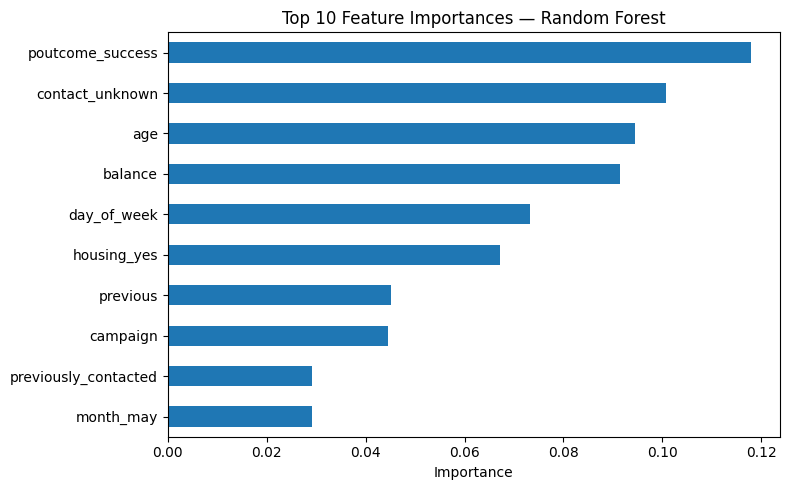

poutcome_success        0.117880
contact_unknown         0.100681
age                     0.094457
balance                 0.091393
day_of_week             0.073157
housing_yes             0.067114
previous                0.045221
campaign                0.044573
previously_contacted    0.029205
month_may               0.029066
dtype: float64


In [ ]:
# Feature importance from best model
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(10)

top_features.plot(kind="barh", figsize=(8, 5))
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(top_features)

In [ ]:
# Lift at top-k (this ties directly to secondary lens)
import numpy as np

def precision_at_k(model, X_test, y_test, k_pct):
    y_proba = model.predict_proba(X_test)[:, 1]
    n_k = int(len(y_test) * k_pct)
    top_k_idx = np.argsort(y_proba)[::-1][:n_k]
    return y_test.iloc[top_k_idx].mean()

for name, model in models.items():
    p20 = precision_at_k(model, X_test, y_test, 0.20)
    print(f"{name}: calling the top 20% highest-scored clients reaches "
          f"{p20:.1%} actual subscribers (base rate: {y_test.mean():.1%})")

Logistic Regression (baseline): calling the top 20% highest-scored clients reaches 33.1% actual subscribers (base rate: 11.7%)
Decision Tree: calling the top 20% highest-scored clients reaches 33.4% actual subscribers (base rate: 11.7%)
Random Forest: calling the top 20% highest-scored clients reaches 34.5% actual subscribers (base rate: 11.7%)
XGBoost: calling the top 20% highest-scored clients reaches 34.8% actual subscribers (base rate: 11.7%)


In [ ]:
# Does contact_unknown cluster by time period?
cleaned = pd.read_csv(f"{data_dir}/bank_cleaned.csv")
pd.crosstab(cleaned["contact"], cleaned["month"], normalize="index").round(3)

month,apr,aug,dec,feb,jan,jul,jun,mar,may,nov,oct,sep
contact,,,,,,,,,,,,
cellular,0.093,0.203,0.006,0.081,0.043,0.197,0.025,0.014,0.182,0.121,0.019,0.016
telephone,0.068,0.085,0.013,0.094,0.044,0.293,0.028,0.018,0.158,0.130,0.045,0.023
unknown,0.000,0.004,0.000,0.001,0.001,0.021,0.348,0.001,0.613,0.004,0.004,0.004


In [ ]:
pd.crosstab(cleaned["month"], cleaned["contact"], normalize="index").round(3)

contact,cellular,telephone,unknown
month,,,
apr,0.930,0.068,0.002
aug,0.952,0.039,0.008
dec,0.813,0.173,0.014
feb,0.892,0.103,0.005
jan,0.902,0.092,0.006
jul,0.836,0.124,0.040
jun,0.136,0.015,0.849
mar,0.874,0.111,0.015
may,0.387,0.033,0.579


In [ ]:
# Ablation test: does the model actually need it?
from sklearn.metrics import average_precision_score

X_train_ablation = X_train.drop(columns=["contact_unknown"])
X_test_ablation = X_test.drop(columns=["contact_unknown"])

xgb_ablation = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss", random_state=42
)
xgb_ablation.fit(X_train_ablation, y_train)

pr_auc_with = average_precision_score(y_test, xgb.predict_proba(X_test)[:, 1])
pr_auc_without = average_precision_score(y_test, xgb_ablation.predict_proba(X_test_ablation)[:, 1])

print(f"PR-AUC with contact_unknown:    {pr_auc_with:.4f}")
print(f"PR-AUC without contact_unknown: {pr_auc_without:.4f}")

PR-AUC with contact_unknown:    0.4311
PR-AUC without contact_unknown: 0.4210


In [ ]:
X_train_final = X_train.drop(columns=["contact_unknown"])
X_test_final = X_test.drop(columns=["contact_unknown"])

final_results = []

def evaluate_model_final(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    final_results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1": round(f1_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_proba), 4),
        "PR-AUC": round(average_precision_score(y_test, y_proba), 4),
    })

log_reg_f = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
log_reg_f.fit(X_train_final, y_train)
evaluate_model_final("Logistic Regression (baseline)", log_reg_f, X_test_final, y_test)

dt_f = DecisionTreeClassifier(class_weight="balanced", max_depth=8, random_state=42)
dt_f.fit(X_train_final, y_train)
evaluate_model_final("Decision Tree", dt_f, X_test_final, y_test)

rf_f = RandomForestClassifier(n_estimators=300, class_weight="balanced", max_depth=12, random_state=42, n_jobs=-1)
rf_f.fit(X_train_final, y_train)
evaluate_model_final("Random Forest", rf_f, X_test_final, y_test)

scale_pos_weight_f = (y_train == 0).sum() / (y_train == 1).sum()
xgb_f = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight_f, eval_metric="logloss", random_state=42
)
xgb_f.fit(X_train_final, y_train)
evaluate_model_final("XGBoost", xgb_f, X_test_final, y_test)

pd.DataFrame(final_results)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression (baseline),0.7621,0.2683,0.5983,0.3705,0.7521,0.3945
1,Decision Tree,0.8533,0.3863,0.4319,0.4079,0.7206,0.3508
2,Random Forest,0.8474,0.3845,0.5066,0.4372,0.7790,0.4098
3,XGBoost,0.8327,0.3643,0.5775,0.4468,0.7708,0.4210


In [ ]:
# Ablation: does class-imbalance weighting actually matter?

xgb_unweighted = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    scale_pos_weight=1,
    eval_metric="logloss", random_state=42
)
xgb_unweighted.fit(X_train_final, y_train)

y_proba_weighted   = xgb_f.predict_proba(X_test_final)[:, 1]
y_proba_unweighted = xgb_unweighted.predict_proba(X_test_final)[:, 1]

from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
)

def score_at_default_threshold(y_true, y_proba):
    y_pred = (y_proba >= 0.5).astype(int)
    return {
        "Precision": round(precision_score(y_true, y_pred), 4),
        "Recall": round(recall_score(y_true, y_pred), 4),
        "F1": round(f1_score(y_true, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_true, y_proba), 4),
        "PR-AUC": round(average_precision_score(y_true, y_proba), 4),
    }

weighting_ablation = pd.DataFrame({
    "XGBoost (scale_pos_weight=ratio)": score_at_default_threshold(y_test, y_proba_weighted),
    "XGBoost (scale_pos_weight=1, unweighted)": score_at_default_threshold(y_test, y_proba_unweighted),
}).T

weighting_ablation

,Precision,Recall,F1,ROC-AUC,PR-AUC
XGBoost (scale_pos_weight=ratio),0.3643,0.5775,0.4468,0.7708,0.421
"XGBoost (scale_pos_weight=1, unweighted)",0.6143,0.2514,0.3568,0.7841,0.427


In [ ]:
import os

train_final_export = X_train_final.copy()
train_final_export["y"] = y_train.values

test_final_export = X_test_final.copy()
test_final_export["y"] = y_test.values

output_dir = f"/content/{REPO_NAME}/Data/PreprocessedData"
train_final_export.to_csv(f"{output_dir}/bank_train_final.csv", index=False)
test_final_export.to_csv(f"{output_dir}/bank_test_final.csv", index=False)

os.chdir(f"/content/{REPO_NAME}")

!git config user.email "deshanxd@gmail.com"
!git config user.name "ThemiyaDeshan"

!git add Data/PreprocessedData
!git commit -m "Add final feature set (contact_unknown removed) for evaluation stage"
!git push

[main 87f5d4d] Add final feature set (contact_unknown removed) for evaluation stage
 2 files changed, 45213 insertions(+)
 create mode 100644 Data/PreprocessedData/bank_test_final.csv
 create mode 100644 Data/PreprocessedData/bank_train_final.csv
Enumerating objects: 9, done.
Counting objects: 100% (9/9), done.
Delta compression using up to 24 threads
Compressing objects: 100% (6/6), done.
Writing objects: 100% (6/6), 751.03 KiB | 4.08 MiB/s, done.
Total 6 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/ThemiyaDeshan/Y03S01_Machine-Lerning_Assignment.git
   22c4a83..87f5d4d  main -> main
